In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

![image.png](attachment:391a8ef2-623e-43dc-b212-b2b244c6f524.png)

In [ ]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        return self.linear2(self.dropout(F.relu(self.linear1(x))))

In [ ]:
d_model = 512
d_ff = 2048

ffn = PositionwiseFeedForward(d_model, d_ff)

In [ ]:
x = torch.randn(2, 10, d_model)  # (batch, seq_len, ?,  ?, ? ,,, ? )
out = ffn(x)
out.shape

torch.Size([2, 10, 512])

In [ ]:
intermediate = ffn.linear1(x)
intermediate.shape

torch.Size([2, 10, 2048])

In [ ]:
# nn.LayerNorm(     )

In [ ]:
x = torch.randn(2, 5, 8) * 5 + 3
x.shape

torch.Size([2, 5, 8])

In [ ]:
x[0, 0].mean(), x[0, 0].std()

(tensor(4.6413), tensor(5.3108))

In [ ]:
ln = nn.LayerNorm(8)
data_ln = ln(x)

In [ ]:
data_ln.shape

torch.Size([2, 5, 8])

In [ ]:
data_ln[0, 0].mean(), data_ln[0, 0].std()

(tensor(-2.9802e-08, grad_fn=<MeanBackward0>),
 tensor(1.0690, grad_fn=<StdBackward0>))

In [ ]:
-0.000000029802,    1.0690

(-2.9802e-08, 1.069)

In [ ]:
class AddNorm(nn.Module):
    def __init__(self, d_model, dropout = 0.1):
        super().__init__()

        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, ffn_out):
        return self.norm(x + self.dropout(ffn_out))


In [ ]:
d_model = 64
d_ff = 256

ffn = PositionwiseFeedForward(d_model, d_ff)
add_norm = AddNorm(d_model)

In [ ]:
x = torch.randn(2, 5, d_model)
ffn_out = ffn(x)
result = add_norm(x, ffn_out)

x.shape, ffn_out.shape, result.shape

(torch.Size([2, 5, 64]), torch.Size([2, 5, 64]), torch.Size([2, 5, 64]))

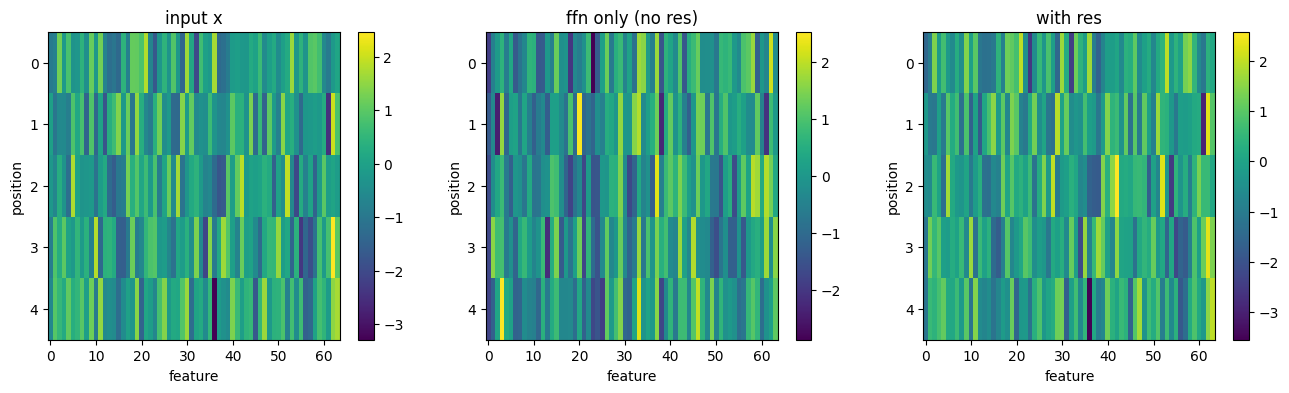

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im0 = axes[0].imshow(x[0].detach().numpy(), cmap='viridis', aspect='auto')
axes[0].set_title('input x')
axes[0].set_xlabel('feature')
axes[0].set_ylabel('position')
plt.colorbar(im0, ax=axes[0])

ffn_only = nn.LayerNorm(d_model)
no_residual = ffn_only(ffn_out)
im1 = axes[1].imshow(no_residual[0].detach().numpy(), cmap='viridis', aspect='auto')
axes[1].set_title('ffn only (no res)')
axes[1].set_xlabel('feature')
axes[1].set_ylabel('position')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(result[0].detach().numpy(), cmap='viridis', aspect='auto')
axes[2].set_title('with res')
axes[2].set_xlabel('feature')
axes[2].set_ylabel('position')
plt.colorbar(im2, ax=axes[2])

plt.show()

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len = 5000, dropout=0.1):
        super().__init__()
        # .__init__() takes from 2 to 3 positional arguments but 4 were given
        # self.pe = PositionalEncoding(d_model, max_len, dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()   # (max_len, 1)

        self.dropout = nn.Dropout(dropout)

        # div_term = 10000 ^ (2i / d_model)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        seq_len = x.size(1)
        x + self.pe[:, :seq_len, :]
        return self.dropout(x)

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """(batch, seq_len, d_model) → (batch, num_heads, seq_len, d_k)"""
        x = x.view(batch_size, -1, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        Q = self.split_heads(self.W_q(q), batch_size)
        K = self.split_heads(self.W_k(k), batch_size)
        V = self.split_heads(self.W_v(v), batch_size)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, V)

        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(output)
        return output, attn_weights


In [ ]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.relu(self.fc1(x))))

![image.png](attachment:098d40a7-d649-4db6-b52c-1c058ef64ae7.png)

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, src_mask=None):
        attn_out, attn_weights = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout1(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))

        return x, attn_weights

![image.png](attachment:a7a4e303-2b9b-4ccc-abbc-713d7de2d4d2.png)

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        self_attn_out, self_attn_weights = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout1(self_attn_out))

        cross_attn_out, cross_attn_weights = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout2(cross_attn_out))

        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout3(ffn_out))

        return x, self_attn_weights, cross_attn_weights



![image.png](attachment:87e88cf1-1352-4e04-af5c-f241e59a3a5c.png)

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len=5000, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe = PositionalEncoding(d_model, max_len, dropout)

        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.d_model = d_model

    def forward(self, src, src_mask=None):
        x = self.embedding(src) * math.sqrt(self.d_model)  # empirical
        x = self.pe(x)

        attn_weights_all = []
        for layer in self.layers:
            x, attn_weight = layer(x, src_mask)
            attn_weights_all.append(attn_weight )

        return x, attn_weights_all


![image.png](attachment:24f4c58a-c1ce-4952-85ca-bdd3060e7ac4.png)

In [ ]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len=5000, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe = PositionalEncoding(d_model, max_len, dropout)

        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.d_model = d_model

    def forward(self, tgt, enc_output, src_mask=None, tgt_mask=None):
        x = self.embedding(tgt) * math.sqrt(self.d_model)  # empirical
        x = self.pe(x)

        self_attn_all, cross_attn_all = [], []
        for layer in self.layers:
            x, self_attn_weight, cross_attn_weight = layer(x, enc_output, src_mask, tgt_mask)
            self_attn_all.append(self_attn_weight)
            cross_attn_all.append(cross_attn_weight)

        return x, self_attn_all, cross_attn_all


In [ ]:
def create_pad_mask(seq, pad_idx=0):
    return (seq != pad_idx).unsqueeze(1).unsqueeze(2) # (batch, 1, 1, seq_len)

def create_causal_mask(size):
    mask = torch.tril(torch.ones(size, size)).unsqueeze(0).unsqueeze(0) # (1,1, size, size)

    return mask

def create_tgt_mask(tgt, pad_idx=0):
    pad_mask = create_pad_mask(tgt, pad_idx)      # (batch, 1, 1, seq_len)
    causal_mask = create_causal_mask(tgt.size(1)) # (1,1, seq_len, seq_len)

    # seq : (2, 5, 16) : (batch, seq_len, d_model)

    return pad_mask & (causal_mask==1)

In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=512, num_heads=8, num_layers=6, d_ff=2044, max_len=5000, dropout=0.1):
        super().__init__()
        self.encoder = TransformerEncoder(src_vocab, d_model, num_heads, num_layers, d_ff, max_len, dropout)
        self.decoder = TransformerDecoder(tgt_vocab, d_model, num_heads, num_layers, d_ff, max_len, dropout)

        self.out_projection = nn.Linear(d_model, tgt_vocab)
        self._init_weights()  #
        # nn.init.xavier_uniform_()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        enc_output, enc_attn = self.encoder(src, src_mask)
        dec_output, dec_self_attn, dec_cross_attn = self.decoder(tgt, enc_output, src_mask, tgt_mask)

        logits = self.out_projection(dec_output)

        return logits, enc_attn, dec_self_attn, dec_cross_attn



In [ ]:
src_vocab = 1000
tgt_vocab = 1000
d_model = 128
num_heads = 4
num_layers = 2
d_ff = 256

model = Transformer(src_vocab=src_vocab, tgt_vocab=tgt_vocab, d_model=d_model, num_heads=num_heads, num_layers=num_layers, d_ff=d_ff)

In [ ]:
src = torch.randint(1, src_vocab, (2, 10))
tgt = torch.randint(1, tgt_vocab, (2, 8))

In [ ]:
src.shape, tgt.shape

(torch.Size([2, 10]), torch.Size([2, 8]))

In [ ]:
src_mask = create_pad_mask(src)
tgt_mask = create_tgt_mask(tgt)

In [ ]:
src

tensor([[276, 697, 915, 181, 935, 146, 894, 442, 664, 892],
        [353, 101,  35, 363, 776, 344, 472, 808,  82, 739]])

In [ ]:
src_mask

tensor([[[[True, True, True, True, True, True, True, True, True, True]]],


        [[[True, True, True, True, True, True, True, True, True, True]]]])

In [ ]:
tgt

tensor([[168, 395, 732, 535, 803, 218, 304, 224],
        [534, 997, 549, 240, 819, 957, 604, 629]])

In [ ]:
tgt_mask

tensor([[[[ True, False, False, False, False, False, False, False],
          [ True,  True, False, False, False, False, False, False],
          [ True,  True,  True, False, False, False, False, False],
          [ True,  True,  True,  True, False, False, False, False],
          [ True,  True,  True,  True,  True, False, False, False],
          [ True,  True,  True,  True,  True,  True, False, False],
          [ True,  True,  True,  True,  True,  True,  True, False],
          [ True,  True,  True,  True,  True,  True,  True,  True]]],


        [[[ True, False, False, False, False, False, False, False],
          [ True,  True, False, False, False, False, False, False],
          [ True,  True,  True, False, False, False, False, False],
          [ True,  True,  True,  True, False, False, False, False],
          [ True,  True,  True,  True,  True, False, False, False],
          [ True,  True,  True,  True,  True,  True, False, False],
          [ True,  True,  True,  True,  True

In [ ]:
logits, enc_attn, dec_self_attn, dec_cross_attn = model(src, tgt, src_mask, tgt_mask)

In [ ]:
src.shape, tgt.shape

(torch.Size([2, 10]), torch.Size([2, 8]))

In [ ]:
logits.shape

torch.Size([2, 8, 1000])

In [ ]:
len(enc_attn), len(dec_self_attn)

(2, 2)

In [ ]:
enc_attn[0].shape, dec_self_attn[0].shape, dec_cross_attn[0].shape

(torch.Size([2, 4, 10, 10]),
 torch.Size([2, 4, 8, 8]),
 torch.Size([2, 4, 8, 10]))

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
total_params

1047528

In [ ]:
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())
proj_params = sum(p.numel() for p in model.out_projection.parameters())

In [ ]:
encoder_params, decoder_params, proj_params

(392960, 525568, 129000)

In [ ]:
392960 + 525568 + proj_params

1047528

In [ ]:
model

Transformer(
  (encoder): TransformerEncoder(
    (embedding): Embedding(1000, 128)
    (pe): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=128, out_features=128, bias=True)
          (W_k): Linear(in_features=128, out_features=128, bias=True)
          (W_v): Linear(in_features=128, out_features=128, bias=True)
          (W_o): Linear(in_features=128, out_features=128, bias=True)
        )
        (ffn): PositionwiseFeedForward(
          (fc1): Linear(in_features=128, out_features=256, bias=True)
          (fc2): Linear(in_features=256, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dro

In [ ]:
from transformers import AutoTokenizer, BartForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, pipeline

/home/oncreative/.local/lib/python3.10/site-packages/librosa/util/files.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
2026-03-11 13:26:26.442708: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773203186.460673 3367384 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773203186.466630 3367384 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773203186.480998 3367384 computation_placer.cc:177] compu

In [ ]:
from datasets import load_dataset

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
summarizer = pipeline('summarization', model='facebook/bart-large-cnn', device=device)

article = """
The Transformer architecture, introduced in the 2017 paper "Attention Is All You Need"
by Vaswani et al., has fundamentally changed the landscape of natural language processing.
Unlike previous sequence-to-sequence models that relied on recurrent neural networks,
the Transformer uses a self-attention mechanism that allows it to process all positions
in the input sequence simultaneously. This parallel processing capability makes it
significantly faster to train than RNN-based models. The architecture consists of an
encoder and a decoder, each composed of multiple layers of multi-head attention and
feed-forward networks. Since its introduction, the Transformer has become the foundation
for models like BERT, GPT, and T5, which have achieved state-of-the-art results on
virtually every NLP benchmark.
"""

summary = summarizer(article, max_length=60, min_length=20)

Device set to use cuda


In [ ]:
summary

[{'summary_text': 'The Transformer architecture has fundamentally changed the landscape of natural language processing. It uses a self-attention mechanism that allows it to process all positions in the input sequence simultaneously. This parallel processing capability makes it significantly faster to train than RNN-based models. Since its introduction, the'}]

In [ ]:
translator = pipeline('translation_en_to_de', model = 'Helsinki-NLP/opus-mt-en-de', device=device)
sentences = [
    "the cat sat on the mat",
    "Attention is all you need",
    "Hello"
]

/home/oncreative/anaconda3/envs/codeit/lib/python3.10/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cuda


In [ ]:
for sent in sentences:
    result = translator(sent)
    print(f"en : {sent}, de : {result}")

en : the cat sat on the mat, de : [{'translation_text': 'die Katze saß auf der Matte'}]
en : Attention is all you need, de : [{'translation_text': 'Achtung ist alles, was du brauchst'}]
en : Hello, de : [{'translation_text': 'Guten Tag.'}]


In [ ]:
result[0]['translation_text']

'Guten Tag.'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('facebook/bart-base')

In [ ]:
tokenizer.bos_token, tokenizer.bos_token_id

('<s>', 0)

In [ ]:
tokenizer.vocab_size

50265

In [ ]:
model = BartForConditionalGeneration.from_pretrained("facebook/bart-base", attn_implementation="eager")

In [ ]:
model

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50265, 768, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50265, 768, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 768)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (final_layer_n

In [ ]:
dataset = load_dataset('xsum')

In [ ]:
len(dataset['train']), len(dataset['validation']), len(dataset['test'])

(204045, 11332, 11334)

In [ ]:
dataset['train'][0]

{'document': 'The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.\nRepair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water.\nTrains on the west coast mainline face disruption due to damage at the Lamington Viaduct.\nMany businesses and householders were affected by flooding in Newton Stewart after the River Cree overflowed into the town.\nFirst Minister Nicola Sturgeon visited the area to inspect the damage.\nThe waters breached a retaining wall, flooding many commercial properties on Victoria Street - the main shopping thoroughfare.\nJeanette Tate, who owns the Cinnamon Cafe which was badly affected, said she could not fault the multi-agency response once the flood hit.\nHowever, she said more preventative work could have been carried out to ensure the retaining wall did not fail.\n"It is difficult but I do think there is so much publicity for Dumfries and the Nith - and I totally apprecia

In [ ]:
small_train = dataset['train'].shuffle().select(range(2000))
small_val = dataset['validation'].shuffle().select(range(500))

In [ ]:
len(small_train)

2000

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('facebook/bart-base')
model = BartForConditionalGeneration.from_pretrained('facebook/bart-base')

In [ ]:
sum(p.numel() for p in model.parameters())

139420416

In [ ]:
MAX_INPUT_LEN = 512
MAX_TARGET_LEN = 64

def preprocess(example):
    model_inputs = tokenizer(example['document'], max_length=MAX_INPUT_LEN, truncation=True, padding='max_length')
    labels = tokenizer(example['summary'], max_length=MAX_TARGET_LEN, truncation=True, padding='max_length')

    labels['input_ids'] = [[(tok if tok != tokenizer.pad_token_id else -100) for tok in label] for label in labels['input_ids']]

    model_inputs['labels'] = labels['input_ids']
    return model_inputs

In [ ]:
train_dataset = small_train.map(preprocess, batched=True, remove_columns = small_train.column_names)
val_dataset = small_val.map(preprocess, batched=True, remove_columns = small_val.column_names)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
train_dataset.set_format('torch')
val_dataset.set_format('torch')

In [ ]:
train_dataset[0]['input_ids']

tensor([    0, 21910,  5333,    34,    56,     7,  2168,     5,  2569,     8,
         5467,    11,    39,  2311,     7, 28527,     5,  1995,  1608, 12170,
            6,    31,    63,  1300,    11,     5, 12093,  9787,     7,     5,
         1608, 12170,  5441, 16705,     4, 50118, 10777,     5,   983,     6,
            5,  2107,    12,   180,    12,   279,  1348,    39,   184,   343,
            9, 25296, 27811,   111,   103,   654,  1788,    36,  2940,  7203,
           43,    31,     5,  2073,     4, 50118,   894,    26,    35,    22,
          100,   348,   202,   300,    10,   251,   169,     7,   213,   111,
           89,    18,   202,   277,   237,   360,     9, 31983,  4908,     7,
          120,   149,    72, 50118,   133, 44090,   880,    39, 14576,  7245,
           36, 10056,  6301,    43, 12973,  6966,    11,   221,  7436, 10839,
          261,     6, 25347,  2459,    15,   883,   772,     4, 50118, 11321,
          172,     6,    37,    34, 11252,   149,   840,  1001, 